# Sensitivity Analysis: Extended Model with Glucagon

This notebook shows treatment simulations for the extended multi-nutrient model with glucagon signaling.

We compare the effects of different treatments on glucose, insulin, and HOMA-IR:
1. Insulin administration
2. Energy expenditure increase
3. Weight loss (fat mass reduction)
4. Reesterification enhancement
5. **Glucagon signaling reduction** (reducing A_gcg parameters)

In [1]:
# Base model imports
import sys
sys.path.append('../multi_nutrient_model')
from multi_nutrient_model import (
    ref_parameters as ref_parameters_base,
    perturbation_steady_state as perturbation_steady_state_base,
    sensitivity_analysis as sensitivity_analysis_base,
    PARAMETER_DESCRIPTIONS as PARAMETER_DESCRIPTIONS_base,
    I0 as I0_base,
    TAU_INS as TAU_INS_base,
    PARAMETER_NAMES as PARAMETER_NAMES_base,
)

# Extended model imports (with glucagon)
from multi_nutrient_model_glucagon import (
    ref_parameters as ref_parameters_ext,
    perturbation_steady_state as perturbation_steady_state_ext,
    sensitivity_analysis as sensitivity_analysis_ext,
    PARAMETER_DESCRIPTIONS as PARAMETER_DESCRIPTIONS_ext,
    I0 as I0_ext,
    GCG0 as GCG0_ext,
    TAU_INS as TAU_INS_ext,
    PARAMETER_NAMES as PARAMETER_NAMES_ext,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.rcParams.update({'font.size': 16, 'font.family': 'Arial', 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14})

In [2]:
# Common parameters
K_i_ketogenesis = 0.2

# Initialize parameters for both models
p_base = ref_parameters_base(K_i_ketogenesis=K_i_ketogenesis)
p_ext = ref_parameters_ext(K_i_ketogenesis=K_i_ketogenesis)

# Reference values for scaling
X_base_scale = {'F': 0.5, 'G': 6.0, 'I': 5.0 / I0_base}
X_ext_scale = {'F': 0.5, 'G': 6.0, 'I': 5.0 / I0_ext, 'GCG': 1.0 / GCG0_ext}

# Obese adipose mass (3x normal)
A_obese = 3.0

print(f"Base model I0: {I0_base:.4f}")
print(f"Extended model I0: {I0_ext:.4f}, GCG0: {GCG0_ext:.4f}")

Base model I0: 0.0556
Extended model I0: 0.0556, GCG0: 0.1495


## Parameter Sensitivity Analysis

Compute sensitivity indices for both models to compare how parameters affect glucose, insulin, and HOMA-IR.

In [3]:
# Define parameter symbols for plotting
PARAMETER_SYMBOLS = {
    "v_energy": r"$v_E$",
    "I_max": r"$I_{max}$",
    "C": r'$C$',
    "h": r'$h$',
    "k_glycolysis": r"$k_{glycolysis}$",
    "k_lactate": r"$k_{lactate}$",
    "k_glucose": r"$k_{glucose}$",
    "k_fatty_acids": r"$k_{fatty\ acids}$",
    "k_3HB": r"$k_{3HB}$",
    "k_lipolysis": r"$k_{lipolysis}$",
    'k_reesterification': r'$k_{reesterification}$',
    'k_ketogenesis': r'$k_{ketogenesis}$',
    'k_gluconeogenesis': r'$k_{GNG,lactate}$',
    'V_glycogenolysis': r'$V_{glycogenolysis}$',
    'K_i_lipolysis': r'$K_{i,lipolysis}$',
    "K_a_glycolysis": r"$K_{a,glycolysis}$",
    "K_i_glycogenolysis": r"$K_{i,glycogenolysis}$",
    "K_i_ketogenesis": r"$K_{i,ketogenesis}$",
    # Glucagon parameters
    "h_gcg": r"$g$",
    "GCG_max": r"$GCG_{max}$",
    "C_gcg": r"$D$",
    "alpha_gcg": r"$\alpha_{gcg}$",
    "K_a_gluconeogenesis": r"$K_{a,gluconeogenesis}$",
    "K_a_glycogenolysis": r"$K_{a,glycogenolysis}$",
    "K_a_ketogenesis": r"$K_{a,ketogenesis}$",
    "A_gcg_gluconeogenesis": r"$A_{gcg,GNG}$",
    "A_gcg_glycogenolysis": r"$A_{gcg,GLY}$",
    "A_gcg_ketogenesis": r"$A_{gcg,KG}$"
}

# Parameters to analyze (common to both models)
SENS_PARAMS_COMMON = [
    "v_energy", "I_max", 'C', "k_glycolysis", "k_lactate", "k_glucose", 
    "k_fatty_acids", "h", "k_3HB", "k_lipolysis", "k_reesterification", 
    "k_ketogenesis", "k_gluconeogenesis", "V_glycogenolysis", "K_i_lipolysis", 
    "K_a_glycolysis", "K_i_glycogenolysis", "K_i_ketogenesis"
]

# Glucagon-specific parameters (only in extended model)
SENS_PARAMS_GLUCAGON = [
    "C_gcg", "h_gcg", "GCG_max",
    "K_a_gluconeogenesis", "K_a_glycogenolysis", "K_a_ketogenesis"
]

In [4]:
# Compute sensitivity indices for OBESE condition (A=3.0) for both models
results_base = {}
results_ext = {}

# Analyze common parameters in both models
for p in SENS_PARAMS_COMMON:
    # Base model (without glucagon)
    S_base = sensitivity_analysis_base(p, 3.0, p=p_base, fold_change=None)
    results_base[p] = S_base
    
    # Extended model (with glucagon)
    S_ext = sensitivity_analysis_ext(p, 3.0, p=p_ext, fold_change=None)
    results_ext[p] = S_ext

# Analyze glucagon-specific parameters only in extended model
for p in SENS_PARAMS_GLUCAGON:
    # Extended model only
    S_ext = sensitivity_analysis_ext(p, 3.0, p=p_ext, fold_change=None)
    results_ext[p] = S_ext

# Create DataFrames
df_sens_base = pd.DataFrame(results_base).T
df_sens_ext = pd.DataFrame(results_ext).T

# Drop the flux columns that are 0 by definition
flux_cols_to_drop = ["v_in_L", "v_in_G", "v_in_F", "v_in_K", "vI", "vIA"]
df_sens_base = df_sens_base.drop(columns=[c for c in flux_cols_to_drop if c in df_sens_base.columns], axis=1)
df_sens_ext = df_sens_ext.drop(columns=[c for c in flux_cols_to_drop if c in df_sens_ext.columns], axis=1)

# Add model labels
df_sens_base["Model"] = "Base (-Glucagon)"
df_sens_ext["Model"] = "Extended (+Glucagon)"

# Add parameter description column
df_sens_base["ParameterDescription"] = [PARAMETER_SYMBOLS.get(p, p) for p in df_sens_base.index]
df_sens_ext["ParameterDescription"] = [PARAMETER_SYMBOLS.get(p, p) for p in df_sens_ext.index]

# Combine for comparison
df_sens_combined = pd.concat([df_sens_base, df_sens_ext])

print("✓ Sensitivity indices computed for both models")

✓ Sensitivity indices computed for both models


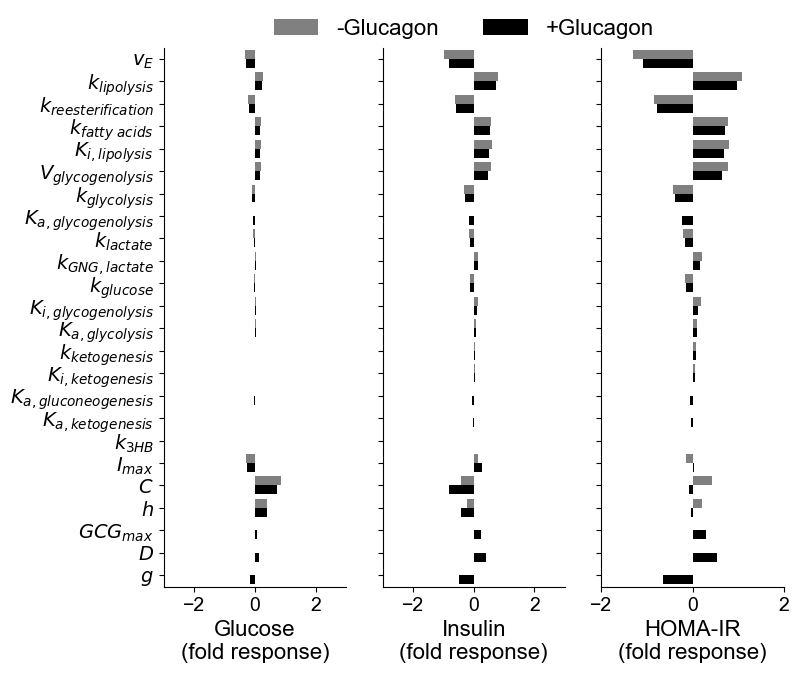

In [5]:
# Create bar graph comparing parameter sensitivities
fig, ax = plt.subplots(1, 3, figsize=(8, 7), sharey=True)

# Order by the HOMA_IR sensitivity (using Extended model)
order = df_sens_ext.groupby("ParameterDescription")["HOMA_IR"].mean()\
            .abs().sort_values(ascending=False).index

# Group insulin sensitivity parameters I_max, C, and h together at the end
# Then group glucagon secretion parameters (C_gcg, h_gcg, GCG_max) at the very end
# K_a parameters are included in the main ranking
insulin_params = [r"$I_{max}$", r'$C$', r'$h$']
glucagon_secretion_params = [r'$GCG_{max}$', r'$D$', r'$g$', ]

# Filter out insulin and glucagon secretion parameters from the main order
# K_a parameters remain in the main ranking by HOMA_IR sensitivity
order = [x for x in order if x not in insulin_params + glucagon_secretion_params]
# Add insulin parameters, then glucagon secretion parameters
order = order + insulin_params + [p for p in glucagon_secretion_params if p in df_sens_ext['ParameterDescription'].values]

# Define colors for the two models
model_colors = ['grey', 'black']

# Glucose sensitivity
sns.barplot(data=df_sens_combined, y="ParameterDescription", x='G', ax=ax[0], 
            order=order, hue="Model", palette=model_colors, legend=False)
ax[0].set_xlim(-3, 3)
ax[0].set_xlabel("Glucose\n(fold response)")
ax[0].set_ylabel("")

# Insulin sensitivity
sns.barplot(data=df_sens_combined, y="ParameterDescription", x='I', ax=ax[1],
            order=order, hue="Model", palette=model_colors, legend=False)
ax[1].set_xlim(-3, 3.0)
ax[1].set_xlabel("Insulin\n(fold response)")
ax[1].set_ylabel("")

# HOMA-IR sensitivity
sns.barplot(data=df_sens_combined, y="ParameterDescription", x='HOMA_IR', ax=ax[2], 
            order=order, hue="Model", palette=model_colors, legend=False)
ax[2].set_xlim(-2, 2.0)
ax[2].set_xlabel("HOMA-IR\n(fold response)")
ax[2].set_ylabel("")

# Add legend
from matplotlib.patches import Rectangle
legend_elements = [
    Rectangle((0,0), 1, 1, facecolor=model_colors[0], label='-Glucagon'),
    Rectangle((0,0), 1, 1, facecolor=model_colors[1], label='+Glucagon')
]


fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.95), # Save the figure

           ncol=2, frameon=False)

sns.despine()

plt.savefig("output/sensitivity_glucose_insulin_homa_ir_comparison.svg", bbox_inches='tight')


## Helper Functions for Comparison

In [6]:
def compute_treatment_response_base(treatment_values, treatment_param, p_base, A=3.0):
    """
    Compute treatment response for the base model (-glucagon).
    
    Returns DataFrame with G, I, HOMA_IR columns.
    """
    results = []
    for val in treatment_values:
        X = perturbation_steady_state_base(A, p=p_base, **{treatment_param: val})
        G = X[1] * X_base_scale['G']  # Glucose in mM
        I = X[4] * X_base_scale['I']  # Insulin in μU/mL
        HOMA_IR = G * I / 22.5
        results.append({'G': G, 'I': I, 'HOMA_IR': HOMA_IR})
    return pd.DataFrame(results)


def compute_treatment_response_ext(treatment_values, treatment_param, p_ext, A=3.0):
    """
    Compute treatment response for the extended model (+glucagon).
    
    Returns DataFrame with G, I, GCG, HOMA_IR columns.
    """
    results = []
    for val in treatment_values:
        X = perturbation_steady_state_ext(A, p=p_ext, **{treatment_param: val})
        G = X[1] * X_ext_scale['G']  # Glucose in mM
        I = X[4] * X_ext_scale['I']  # Insulin in μU/mL
        GCG = X[6] * X_ext_scale['GCG']  # Glucagon (normalized)
        HOMA_IR = G * I / 22.5
        results.append({'G': G, 'I': I, 'GCG': GCG, 'HOMA_IR': HOMA_IR})
    return pd.DataFrame(results)


def compute_adipose_response_base(A_values, p_base):
    """
    Compute response to varying adipose mass for base model.
    """
    results = []
    for A in A_values:
        X = perturbation_steady_state_base(A, p=p_base)
        G = X[1] * X_base_scale['G']
        I = X[4] * X_base_scale['I']
        HOMA_IR = G * I / 22.5
        results.append({'G': G, 'I': I, 'HOMA_IR': HOMA_IR})
    return pd.DataFrame(results)


def compute_adipose_response_ext(A_values, p_ext):
    """
    Compute response to varying adipose mass for extended model.
    """
    results = []
    for A in A_values:
        X = perturbation_steady_state_ext(A, p=p_ext)
        G = X[1] * X_ext_scale['G']
        I = X[4] * X_ext_scale['I']
        GCG = X[6] * X_ext_scale['GCG']
        HOMA_IR = G * I / 22.5
        results.append({'G': G, 'I': I, 'GCG': GCG, 'HOMA_IR': HOMA_IR})
    return pd.DataFrame(results)

## Treatment Simulations Comparison

Compare four treatment strategies between the base model (-glucagon) and extended model (+glucagon):
1. **Insulin administration** - Exogenous insulin infusion
2. **Energy expenditure** - Increased metabolic rate
3. **Weight loss** - Reduction in adipose mass
4. **Reesterification** - Enhanced fatty acid re-esterification

In [7]:
# 1. Insulin administration
I_dose_base = I0_base / TAU_INS_base
I_dose_ext = I0_ext / TAU_INS_ext
C_values = np.linspace(0, 3.5, 100)

# Scale to daily dose (matching sensitivity_analysis.ipynb)
scaling = 1.25 / 1000 * 60 * 24 * 0.081

# Base model
C_base = C_values * I0_base / TAU_INS_base
X_ins_base = compute_treatment_response_base(C_base, 'R_insulin', p_base, A=3.0)
X_ins_base['dose'] = C_values * scaling
X_ins_base['model'] = 'Base (-Glucagon)'

# Extended model
C_ext = C_values * I0_ext / TAU_INS_ext
X_ins_ext = compute_treatment_response_ext(C_ext, 'R_insulin', p_ext, A=3.0)
X_ins_ext['dose'] = C_values * scaling
X_ins_ext['model'] = 'Extended (+Glucagon)'

df_insulin = pd.concat([X_ins_base, X_ins_ext], ignore_index=True)
print("✓ Insulin administration computed")

✓ Insulin administration computed


In [8]:
# 2. Energy expenditure
vE_values = np.linspace(1, 3, 100)

# Base model
X_vE_base = compute_treatment_response_base(vE_values, 'v_energy', p_base, A=3.0)
X_vE_base['vE'] = vE_values
X_vE_base['model'] = 'Base (-Glucagon)'

# Extended model
X_vE_ext = compute_treatment_response_ext(vE_values, 'v_energy', p_ext, A=3.0)
X_vE_ext['vE'] = vE_values
X_vE_ext['model'] = 'Extended (+Glucagon)'

df_energy = pd.concat([X_vE_base, X_vE_ext], ignore_index=True)
print("✓ Energy expenditure computed")

✓ Energy expenditure computed


In [9]:
# 3. Weight loss (varying adipose mass from 3x to 1x)
A_values = np.linspace(3, 1, 100)

# Base model
X_wl_base = compute_adipose_response_base(A_values, p_base)
# Convert to absolute weight loss (kg fat)
# Normal fat mass 18% of 75 kg is 13.5 kg, 3x is 40.5 kg
X_wl_base['fm_delta'] = (3 - A_values) * 13.5
X_wl_base['model'] = 'Base (-Glucagon)'

# Extended model
X_wl_ext = compute_adipose_response_ext(A_values, p_ext)
X_wl_ext['fm_delta'] = (3 - A_values) * 13.5
X_wl_ext['model'] = 'Extended (+Glucagon)'

df_weight = pd.concat([X_wl_base, X_wl_ext], ignore_index=True)
print("✓ Weight loss computed")

✓ Weight loss computed


In [10]:
# 4. Reesterification enhancement
VR_ix_base = PARAMETER_NAMES_base.index("k_reesterification")
VR_ix_ext = PARAMETER_NAMES_ext.index("k_reesterification")

k_re_multipliers = np.linspace(1, 4, 100)

# Base model
k_re_base = k_re_multipliers * p_base[VR_ix_base]
X_re_base = compute_treatment_response_base(k_re_base, 'k_reesterification', p_base, A=3.0)
X_re_base['k_re_fold'] = k_re_multipliers
X_re_base['model'] = 'Base (-Glucagon)'

# Extended model
k_re_ext = k_re_multipliers * p_ext[VR_ix_ext]
X_re_ext = compute_treatment_response_ext(k_re_ext, 'k_reesterification', p_ext, A=3.0)
X_re_ext['k_re_fold'] = k_re_multipliers
X_re_ext['model'] = 'Extended (+Glucagon)'

df_reester = pd.concat([X_re_base, X_re_ext], ignore_index=True)
print("✓ Reesterification computed")

✓ Reesterification computed


In [11]:
# 5. Lipolysis reduction
k_lipo_ix_base = PARAMETER_NAMES_base.index("k_lipolysis")
k_lipo_ix_ext = PARAMETER_NAMES_ext.index("k_lipolysis")

k_lipo_multipliers = np.linspace(1, 0.32, 100)

# Base model
k_lipo_base = k_lipo_multipliers * p_base[k_lipo_ix_base]
X_lipo_base = compute_treatment_response_base(k_lipo_base, 'k_lipolysis', p_base, A=3.0)
X_lipo_base['lipolysis_inhibition'] = (1 - k_lipo_multipliers) * 100
X_lipo_base['model'] = 'Base (-Glucagon)'

# Extended model
k_lipo_ext = k_lipo_multipliers * p_ext[k_lipo_ix_ext]
X_lipo_ext = compute_treatment_response_ext(k_lipo_ext, 'k_lipolysis', p_ext, A=3.0)
X_lipo_ext['lipolysis_inhibition'] = (1 - k_lipo_multipliers) * 100
X_lipo_ext['model'] = 'Extended (+Glucagon)'

df_lipolysis = pd.concat([X_lipo_base, X_lipo_ext], ignore_index=True)
print("✓ Lipolysis computed")

✓ Lipolysis computed


In [12]:
# 6. Glucagon signaling reduction (reducing A_gcg parameters)
# Get baseline A_gcg values from p_ext
A_gcg_gng_ix = PARAMETER_NAMES_ext.index("A_gcg_gluconeogenesis")
A_gcg_gly_ix = PARAMETER_NAMES_ext.index("A_gcg_glycogenolysis")
A_gcg_kg_ix = PARAMETER_NAMES_ext.index("A_gcg_ketogenesis")

A_gcg_base = p_ext[A_gcg_gng_ix]  # All A_gcg params have same baseline value

# Reduce A_gcg from 100% to 0% (full glucagon signaling to no glucagon signaling)
A_gcg_multipliers = np.linspace(1, 0, 100)

# Compute response - reduce all three A_gcg parameters proportionally
results_gcg = []
for mult in A_gcg_multipliers:
    A_gcg_val = A_gcg_base * mult
    X = perturbation_steady_state_ext(3.0, p=p_ext, 
                                       A_gcg_gluconeogenesis=A_gcg_val,
                                       A_gcg_glycogenolysis=A_gcg_val,
                                       A_gcg_ketogenesis=A_gcg_val)
    G = X[1] * X_ext_scale['G']
    I = X[4] * X_ext_scale['I']
    GCG = X[6] * X_ext_scale['GCG']
    HOMA_IR = G * I / 22.5
    results_gcg.append({'G': G, 'I': I, 'GCG': GCG, 'HOMA_IR': HOMA_IR, 'A_gcg_reduction': (1 - mult) * 100})

X_gcg_ext = pd.DataFrame(results_gcg)
print("✓ Glucagon signaling reduction computed")

✓ Glucagon signaling reduction computed


## Treatment Effects on Glucose, Insulin, and HOMA-IR (Extended Model with Glucagon)

In [13]:
# Colors 
colors = {
    'Insulin': '#d881b5' , 
    'Glucagon_Inhibition': '#898989',
    'Exercise': '#2ab9d8',
    'Weight_Loss': '#5eb246',
    'Reesterification': '#cd7f29',
    'Lipolysis_Inhibition': "#417c30"

}

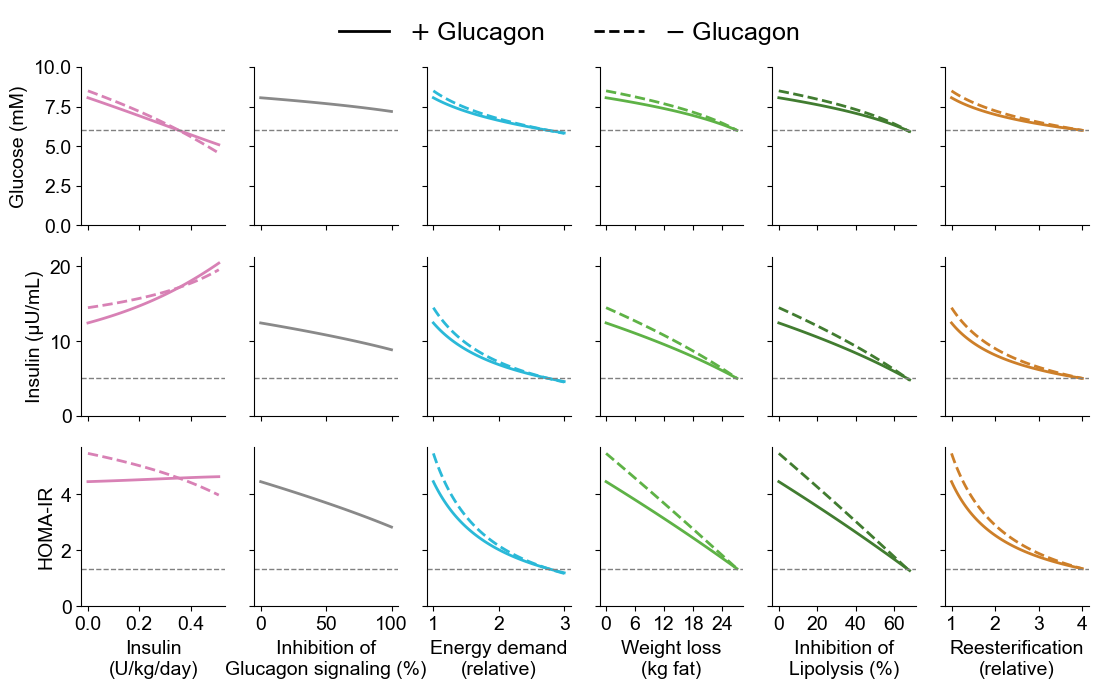

In [16]:
# Plot matching the original sensitivity_analysis.ipynb style
# Extended model = solid lines, Base model = dashed lines
fig, ax = plt.subplots(3, 6, figsize=(13, 7), sharey='row', sharex='col')

# 1. Insulin administration (column 0)
sns.lineplot(data=X_ins_ext, x='dose', y="G", ax=ax[0,0], color=colors['Insulin'], linewidth=2)
sns.lineplot(data=X_ins_base, x='dose', y="G", ax=ax[0,0], color=colors['Insulin'], linewidth=2, linestyle='--')
sns.lineplot(data=X_ins_ext, x='dose', y="I", ax=ax[1,0], color=colors['Insulin'], linewidth=2)
sns.lineplot(data=X_ins_base, x='dose', y="I", ax=ax[1,0], color=colors['Insulin'], linewidth=2, linestyle='--')
sns.lineplot(data=X_ins_ext, x='dose', y="HOMA_IR", ax=ax[2,0], color=colors['Insulin'], linewidth=2)
sns.lineplot(data=X_ins_base, x='dose', y="HOMA_IR", ax=ax[2,0], color=colors['Insulin'], linewidth=2, linestyle='--')

# 2. Glucagon signaling reduction (column 1) - only extended model
sns.lineplot(data=X_gcg_ext, x='A_gcg_reduction', y="G", ax=ax[0,1], color=colors['Glucagon_Inhibition'], linewidth=2)
sns.lineplot(data=X_gcg_ext, x='A_gcg_reduction', y="I", ax=ax[1,1], color=colors['Glucagon_Inhibition'], linewidth=2)
sns.lineplot(data=X_gcg_ext, x='A_gcg_reduction', y="HOMA_IR", ax=ax[2,1], color=colors['Glucagon_Inhibition'], linewidth=2)

# 3. Energy expenditure (column 2)
sns.lineplot(data=X_vE_ext, x='vE', y="G", ax=ax[0,2], color=colors['Exercise'], linewidth=2)
sns.lineplot(data=X_vE_base, x='vE', y="G", ax=ax[0,2], color=colors['Exercise'], linewidth=2, linestyle='--')
sns.lineplot(data=X_vE_ext, x='vE', y="I", ax=ax[1,2], color=colors['Exercise'], linewidth=2)
sns.lineplot(data=X_vE_base, x='vE', y="I", ax=ax[1,2], color=colors['Exercise'], linewidth=2, linestyle='--')
sns.lineplot(data=X_vE_ext, x='vE', y="HOMA_IR", ax=ax[2,2], color=colors['Exercise'], linewidth=2)
sns.lineplot(data=X_vE_base, x='vE', y="HOMA_IR", ax=ax[2,2], color=colors['Exercise'], linewidth=2, linestyle='--')

# 4. Weight loss (column 3)
sns.lineplot(data=X_wl_ext, x='fm_delta', y="G", ax=ax[0,3], color=colors['Weight_Loss'], linewidth=2)
sns.lineplot(data=X_wl_base, x='fm_delta', y="G", ax=ax[0,3], color=colors['Weight_Loss'], linewidth=2, linestyle='--')
sns.lineplot(data=X_wl_ext, x='fm_delta', y="I", ax=ax[1,3], color=colors['Weight_Loss'], linewidth=2)
sns.lineplot(data=X_wl_base, x='fm_delta', y="I", ax=ax[1,3], color=colors['Weight_Loss'], linewidth=2, linestyle='--')
sns.lineplot(data=X_wl_ext, x='fm_delta', y="HOMA_IR", ax=ax[2,3], color=colors['Weight_Loss'], linewidth=2)
sns.lineplot(data=X_wl_base, x='fm_delta', y="HOMA_IR", ax=ax[2,3], color=colors['Weight_Loss'], linewidth=2, linestyle='--')


# 5. Lipolysis (column 4)
sns.lineplot(data=X_lipo_ext, x='lipolysis_inhibition', y="G", ax=ax[0,4], color=colors['Lipolysis_Inhibition'], linewidth=2)
sns.lineplot(data=X_lipo_base, x='lipolysis_inhibition', y="G", ax=ax[0,4], color=colors['Lipolysis_Inhibition'], linewidth=2, linestyle='--')
sns.lineplot(data=X_lipo_ext, x='lipolysis_inhibition', y="I", ax=ax[1,4], color=colors['Lipolysis_Inhibition'], linewidth=2)
sns.lineplot(data=X_lipo_base, x='lipolysis_inhibition', y="I", ax=ax[1,4], color=colors['Lipolysis_Inhibition'], linewidth=2, linestyle='--')
sns.lineplot(data=X_lipo_ext, x='lipolysis_inhibition', y="HOMA_IR", ax=ax[2,4], color=colors['Lipolysis_Inhibition'], linewidth=2)
sns.lineplot(data=X_lipo_base, x='lipolysis_inhibition', y="HOMA_IR", ax=ax[2,4], color=colors['Lipolysis_Inhibition'], linewidth=2, linestyle='--')

# 6. Reesterification (column 5)
sns.lineplot(data=X_re_ext, x='k_re_fold', y="G", ax=ax[0,5], color=colors['Reesterification'], linewidth=2)
sns.lineplot(data=X_re_base, x='k_re_fold', y="G", ax=ax[0,5], color=colors['Reesterification'], linewidth=2, linestyle='--')
sns.lineplot(data=X_re_ext, x='k_re_fold', y="I", ax=ax[1,5], color=colors['Reesterification'], linewidth=2)
sns.lineplot(data=X_re_base, x='k_re_fold', y="I", ax=ax[1,5], color=colors['Reesterification'], linewidth=2, linestyle='--')
sns.lineplot(data=X_re_ext, x='k_re_fold', y="HOMA_IR", ax=ax[2,5], color=colors['Reesterification'], linewidth=2)
sns.lineplot(data=X_re_base, x='k_re_fold', y="HOMA_IR", ax=ax[2,5], color=colors['Reesterification'], linewidth=2, linestyle='--')

# Set y labels
ax[0,0].set_ylabel("Glucose (mM)", fontsize=14)
ax[1,0].set_ylabel("Insulin (μU/mL)", fontsize=14)
ax[2,0].set_ylabel("HOMA-IR", fontsize=14)

# Change lower limit of y axis to 0 
for a in ax.flatten():
    a.set_ylim(bottom=0)

# Set x labels
ax[2,0].set_xlabel("Insulin\n(U/kg/day)", fontsize=14)
ax[2,1].set_xlabel("Inhibition of\nGlucagon signaling (%)", fontsize=14)
ax[2,2].set_xlabel("Energy demand\n(relative)", fontsize=14)
ax[2,3].set_xlabel("Weight loss\n(kg fat)", fontsize=14)
ax[2,4].set_xlabel("Inhibition of\nLipolysis (%)", fontsize=14)
ax[2,5].set_xlabel("Reesterification\n(relative)", fontsize=14)

# Insulin x-ticks
ax[2,0].set_xticks([0, 0.2, 0.4])

# Glucagon inhibition x-ticks
ax[2,1].set_xticks([0, 50, 100])

# Weight loss x-ticks (matching original)
ax[2,3].set_xticks([0, 6, 12, 18, 24])

# Reesterification x-ticks
ax[2,5].set_xticks([1, 2, 3, 4])

# Lipolysis x-ticks
ax[2,4].set_xticks([0, 20, 40, 60])

# Set glucose y limit
ax[0,0].set_ylim(0, 10)

# Add horizontal lines for healthy reference levels
for i in range(6):
    ax[0,i].axhline(6.0, color='grey', linestyle='--', linewidth=1)
    ax[1,i].axhline(5.0, color='grey', linestyle='--', linewidth=1)
    ax[2,i].axhline(6 * 5/22.5, color='grey', linestyle='--', linewidth=1)

# Create custom legend with black lines at top of figure
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='$+$ Glucagon'),
    Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='$-$ Glucagon')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.98), 
           ncol=2, fontsize=18, frameon=False)

sns.despine()

# Save the figure
plt.savefig("output/sensitivity_perturbations_glucagon_model.svg", bbox_inches='tight')
plt.show()